In [1]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pylab as plt

import warnings # To suppress some warnings
 
# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Define folders paths
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

In [3]:
# Assign variables to the files
# Not used
AIRLINE_STATS_CSV = DATA / 'airline_stats.csv'
KC_TAX_CSV = DATA / 'kc_tax.csv.gz'
LC_LOANS_CSV = DATA / 'lc_loans.csv'
AIRPORT_DELAYS_CSV = DATA / 'dfw_airline.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'
SP500_SECTORS_CSV = DATA / 'sp500_sectors.csv'
STATE_CSV = DATA / 'state.csv'

# Sampling Distribution of a Statistic

In [4]:
# Load the loan income data
# Display the first 5 rows
loans_income = pd.read_csv('loans_income.csv').squeeze('columns')
loans_income.head()

0     67000
1     52000
2    100000
3     78762
4     37041
Name: x, dtype: int64

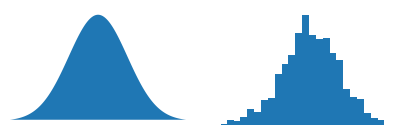

In [5]:

np.random.seed(seed=1)
x = np.linspace(-3,3,300)
xsample = stats.norm.rvs(size=1000)

# Create plot of a normal distribution
fig, axes = plt.subplots(ncols=2, figsize=(5,1.5))
ax = axes[0]
ax.fill(x, stats.norm.pdf(x))
ax.set_axis_off()
ax.set_xlim(-3,3)

# Create histogram of sample normalize data
ax=axes[1]
ax.hist(xsample, bins=30)
ax.set_axis_off()
ax.set_xlim(-3,3)
ax.set_position

plt.show()

### Sampling Distribution of a Statistic

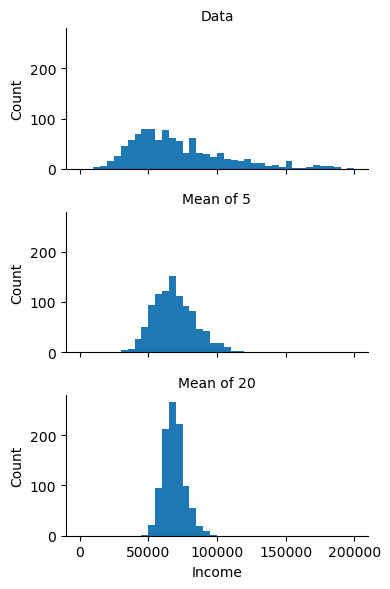

In [6]:
# Create sample of 1000 loans
sample_data = pd.DataFrame({
    "income":loans_income.sample(1000),
    "type":"Data"
})

# Create sample of 1000 means of 5 values
sample_mean_05 = pd.DataFrame({
    "income":[loans_income.sample(5).mean() for _ in range(1000)],
    "type": "Mean of 5"
})

# Create sample of 1000 means of 20 values
sample_mean_20 = pd.DataFrame({
    "income": [loans_income.sample(20).mean() for _ in range(1000)],
    "type":"Mean of 20"
})

# Create a concatenate dataframe of the 3 different samples
results = pd.concat([sample_data, sample_mean_05, sample_mean_20])

# Create a 3 column histogram 
g = sns.FacetGrid(data=results, col='type', col_wrap=1, height=2, aspect=2)
g.map(plt.hist, 'income', range=[0,200000], bins=40)
g.set_axis_labels("Income","Count")
g.set_titles('{col_name}') # this is associated with the col='type'
plt.tight_layout()
plt.show()

# The Bootstrap

In [7]:
# Create a bootstrap resampling  model
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)
print(f"Bootstrap Statistics")
print(f"Original: {loans_income.median()}")
print(f"Bias: {results.mean() - loans_income.median()}")
print(f"Std Error: {results.std()}")

Bootstrap Statistics
Original: 62000.0
Bias: -82.09799999999814
Std Error: 228.73933106830748


# Confidence Intervals

68760.51844
55734.1


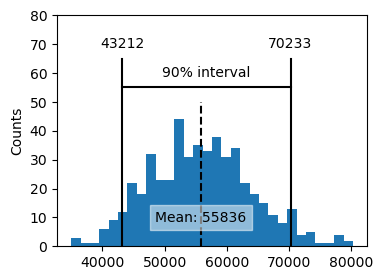

In [8]:
print(loans_income.mean())
np.random.seed(seed=3)

# Create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)
print(sample20.mean())

results = []

for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))

# Create the histogram of the sample
ax = results.plot.hist(bins=30, figsize=(4,3))

# Plot the horizontal confidence interval line at 43212 and 70233 at a height of 55
ax.plot(confidence_interval, [55,55], color='black')

# Plot the vertical confidence interval lines at 43212 and 70233 
for x in confidence_interval:
    ax.plot([x,x], [0,65], color='black')
    ax.text(x, 70, f"{x:.0f}",
           horizontalalignment='center', verticalalignment='center')

# Prints the text '90% interval at height 60 in the middle of the confidence interval'
ax.text(sum(confidence_interval)/2, 60, '90% interval',
       horizontalalignment="center", verticalalignment="center")

meanIncome = results.mean()

# Plot the mean income line with a height of 50
ax.plot([meanIncome, meanIncome], [0,50], color="black", linestyle="--")

# Create the mean income text "Mean: 55836" in the middle at height 10
ax.text(meanIncome, 10, f"Mean: {meanIncome:.0f}",
        bbox=dict(facecolor="white", edgecolor="white", alpha=0.5),
        horizontalalignment="center", verticalalignment="center")

ax.set_ylim(0,80)
ax.set_ylabel("Counts")
plt.tight_layout
plt.show()
    

# Normal Distribution
## Standard Normal and QQ-Plots

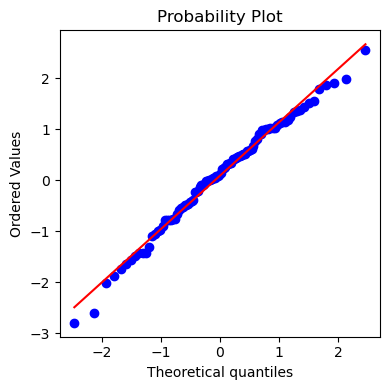

In [9]:
# PLot QQ probability plot
fig, ax = plt.subplots(figsize=(4, 4))

norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax)

plt.tight_layout()
plt.show()

# Long-Tailed Distributions

In [10]:
# Load sp500  and display the first 3 rows
sp500_px = pd.read_csv('sp500_data.csv.gz')
sp500_px.head(3)

,Unnamed: 0,ADS,CA,MSFT,RHT,CTSH,CSC,EMC,IBM,XRX,...,WAT,ALXN,AMGN,BXLT,BIIB,CELG,GILD,REGN,VRTX,HSIC
0,1993-01-29,0.0,0.060124,-0.022100,0.0,0.0,0.018897,0.007368,0.092165,0.259140,...,0.0,0.0,0.34716,0.0,0.04167,0.00000,0.015564,1.75,0.125,0.0
1,1993-02-01,0.0,-0.180389,0.027621,0.0,0.0,0.018889,0.018425,0.115207,-0.100775,...,0.0,0.0,-0.23144,0.0,0.00000,-0.01041,0.007782,1.25,0.125,0.0
2,1993-02-02,0.0,-0.120257,0.035900,0.0,0.0,-0.075573,0.029482,-0.023041,0.028796,...,0.0,0.0,-0.11572,0.0,0.00000,0.00000,-0.007792,-0.25,0.000,0.0


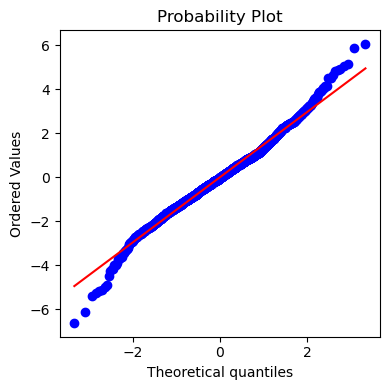

In [11]:
# Create a qqplot of the sp500 data for the company NFLX
nflx = sp500_px["NFLX"]

# Keep only NLFX records where the value is greater than zero
# Apply the natural logarithm to the filtered data
# Calculate the difference between consecutive rows in the log-transformed time series
nflx = np.diff(np.log(nflx[nflx>0]))

fig, ax = plt.subplots(figsize=(4,4))
stats.probplot(nflx, plot=ax)
plt.tight_layout()
plt.show()

# Binomial Distribution

In [12]:
# the probability ofsample observing exactly 2 successes in five trials where
# the probability of success for each trail is 0.1

# probability at a specific point
stats.binom.pmf(2, n=5, p=0.1)

0.07289999999999992

In [13]:
# the probability of observing 2 or fewer successes in five trials where 
#the probability of success for each trail is 0.1

# cumulative probability
stats.binom.cdf(2, n=5, p=0.1)

0.99144

# Poisson and Related Distribution
## Poisson Distributions

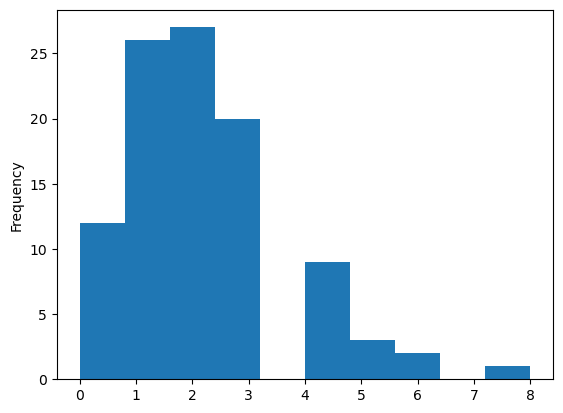

In [14]:
# The Poisson distribution is a discrete probability distribution that 
# describes the probability of a given number of events occurring in a 
# fixed interval of time or space if these events occur with a known average rate.

# The 2 is the lambda value representing the number of events that occurs in a specified
# interval of time or space
sample = stats.poisson.rvs(2, size=100)
pd.Series(sample).plot.hist()
plt.show()

## Exponential Distribution

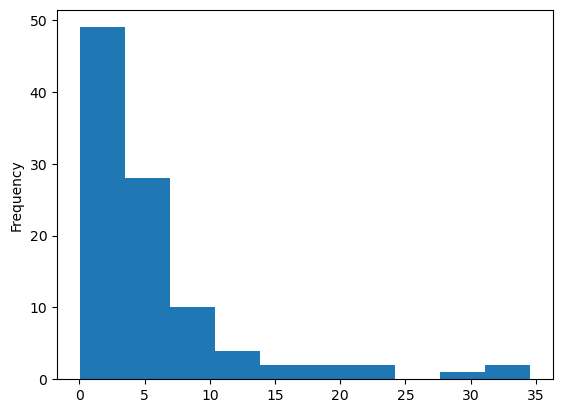

In [15]:
# The exponential distribution is a continuous probability distribution that 
# models the time between events in a Poisson process, where events occur 
# continuously and independently at a constant average rate

sample = stats.expon.rvs(scale=5, size=100)
pd.Series(sample).plot.hist()
plt.show()

##  Weibull Distribution

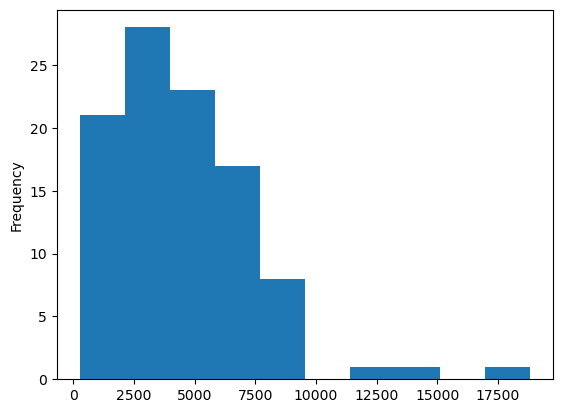

In [16]:
# The Weibull distribution is a continuous probability distribution that is 
# often used to model time-to-event data, such as the failure of a component 
# or the lifespan of an organism. It is also used in other fields, such as 
# wind energy and finance. The distribution is characterized by two 
# parameters: a shape parameter (k) and a scale parameter (λ).

sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)
pd.Series(sample).plot.hist()
plt.show()